# Fraud Detection Analysis (PaySim Dataset)

## Business Context
Financial fraud is a major challenge for digital payment platforms. Detecting
fraudulent transactions early is critical to preventing financial loss and
maintaining user trust.

This project analyses a synthetic financial dataset generated using the PaySim
simulator to identify behavioural patterns associated with fraudulent transactions.

## Objective
The goal of this analysis is to:
- Understand transaction behaviour
- Identify patterns associated with fraud
- Engineer meaningful features for fraud detection
- Provide insights to support fraud prevention strategies

Visuals

In [ ]:
PRIMARY = "#2C3E50"     # dark blue
ACCENT = "#E74C3C"      # fraud highlight (red)
SECONDARY = "#3498DB"   # normal transactions
NEUTRAL = "#95A5A6"     # background comparison

Imports

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

Load the dataset

In [152]:
df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [153]:
df.shape



(6362620, 11)

## Dataset Overview

The dataset contains simulated mobile money transactions with the following key features:

- **step**: Time unit (simulation step)
- **type**: Transaction type (TRANSFER, CASH_OUT, etc.)
- **amount**: Transaction value
- **oldbalanceOrg / newbalanceOrig**: Sender balance before/after
- **oldbalanceDest / newbalanceDest**: Receiver balance before/after
- **isFraud**: Fraud indicator (1 = Fraud, 0 = Normal)
- **isFlaggedFraud**: System-flagged fraud indicator


## Data Cleaning



We begin by checking for missing values, duplicates, and general data consistency.

In [154]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## Feature Engineering

To better capture transactional behaviour, we engineer additional features
based on financial logic and observed patterns.

In [228]:
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

df['balance_error'] = (
    df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
)

df['zero_balance_error'] = df['balance_error'] == 0

df['high_amount'] = df['amount'] > df['amount'].quantile(0.90)

df['log_amount'] = np.log1p(df['amount'])

df['amount_to_balance_ratio'] = (
    df['amount'] / (df['oldbalanceOrg'] + 1)
)

In [174]:
df.groupby('isFraud')['balance_error'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,-201338.558109,606928.890826,-92445516.64,-249953.43,-69049.31,-3034.305,1.000000e-02
1,8213.0,-10692.325265,265146.131130,-10000000.00,0.00,0.00,0.000,3.725290e-09


Fraudulent transactions has 0 as median and for the 25th and 75th percentile.

## Exploratory Data Analysis
### Fraud Distribution



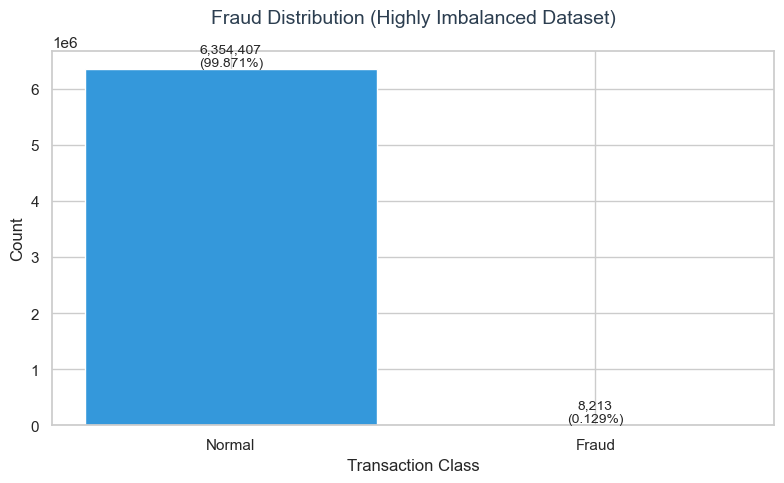

In [ ]:
plt.figure(figsize=(8, 5))

fraud_counts = df['isFraud'].value_counts().sort_index()
fraud_percent = df['isFraud'].value_counts(normalize=True).sort_index() * 100

bars = plt.bar(
    ['Normal', 'Fraud'],
    fraud_counts.values,
    color=[SECONDARY, ACCENT]
)

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{fraud_counts[i]:,}\n({fraud_percent[i]:.3f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title(
    "Fraud Distribution (Highly Imbalanced Dataset)",
    color=PRIMARY,
    pad=20   
)

plt.ylabel("Count")
plt.xlabel("Transaction Class")

plt.tight_layout()
plt.show()




Fraudulent transactions represent only a very small proportion of the dataset,
confirming that this is a highly imbalanced fraud detection problem.

### Transaction Type Distribution


Understanding transaction type frequencies provides context for how activity
is distributed across the platform.

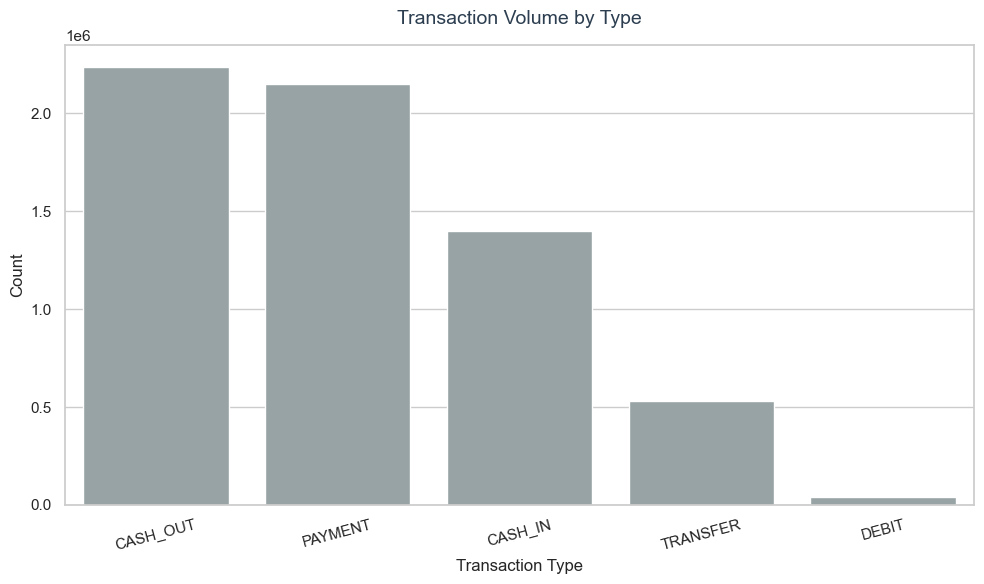

In [212]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='type',
    order=df['type'].value_counts().index,
    color=NEUTRAL   
)

plt.title("Transaction Volume by Type", fontsize=14, color=PRIMARY, pad=15)
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Fraud by transaction

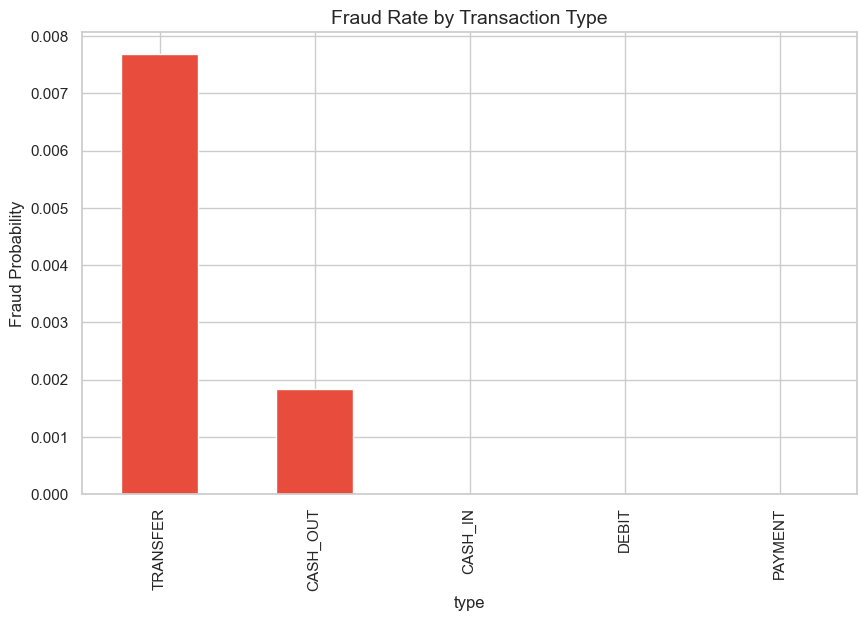

In [201]:
fraud_rate_type = (
    df.groupby('type')['isFraud']
      .mean()
      .sort_values(ascending=False)
)

fraud_rate_type.plot(
    kind='bar',
    color=ACCENT
)

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Probability")
plt.show()

Fraud is overwhelmingly concentrated within TRANSFER and CASH_OUT
transactions, while other transaction types exhibit near-zero fraud rates.
This suggests fraudsters primarily exploit direct fund transfer operations.

### Transaction Amount Distribution

### Fraud Risk Segmentation

Combining behavioural indicators reveals that fraud risk increases
significantly when multiple conditions occur simultaneously,
particularly for TRANSFER and CASH_OUT transactions with perfect
balance reconciliation and high transaction amounts.

This demonstrates that fraud detection benefits from combining
multiple weak signals into a stronger composite risk profile.

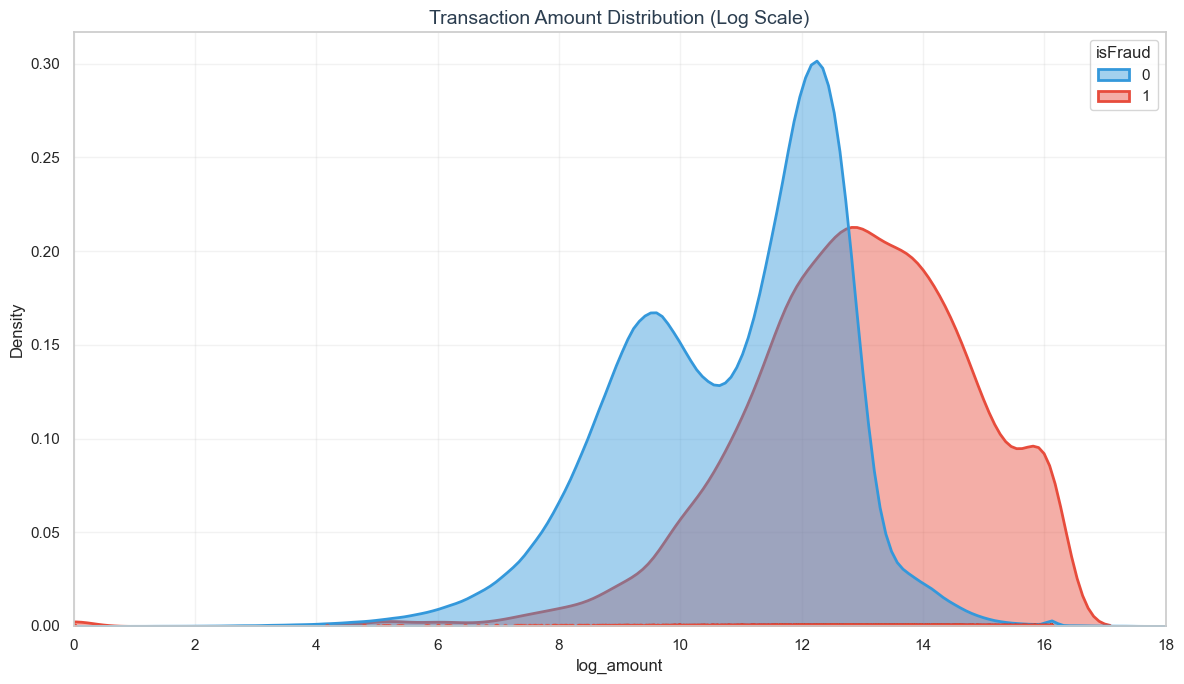

In [213]:
df['log_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df,
    x='log_amount',
    hue='isFraud',
    fill=True,
    common_norm=False,
    alpha=0.45,
    linewidth=2,
    palette=[SECONDARY, ACCENT]
)

fraud_points = df[df['isFraud'] == 1]['log_amount']
plt.scatter(
    fraud_points,
    np.zeros(len(fraud_points)),
    color=ACCENT,
    s=8,
    alpha=0.35,
    label='Fraud points'
)

plt.title("Transaction Amount Distribution (Log Scale)", fontsize=14, color=PRIMARY)
plt.xlabel("log_amount")
plt.ylabel("Density")
plt.xlim(0, 18)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Transaction amounts are highly skewed, so a log transformation is used
to compare fraud and non-fraud behaviour more clearly.

### Balance Consistency Analysis

A balance consistency feature was created to test whether sender account balances
update as expected after a transaction.

/var/folders/9s/vfq5h5s12kd_c7ph353p5wsm0000gn/T/ipykernel_40452/3194956636.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


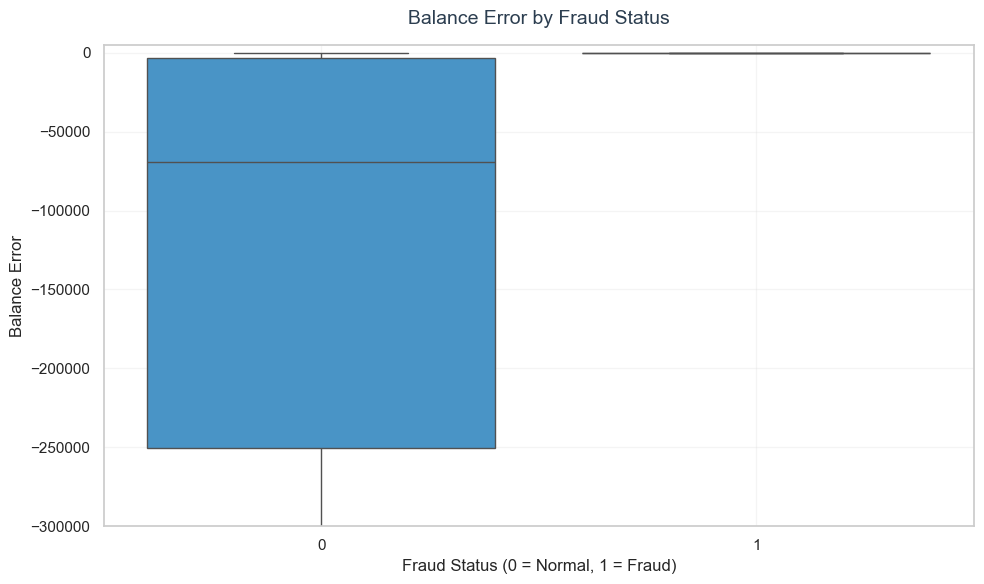

In [216]:
plt.figure(figsize=(10, 6))

# Stratified sample
df_fraud = df[df['isFraud'] == 1]
df_normal = df[df['isFraud'] == 0].sample(200000, random_state=42)
sample_df = pd.concat([df_fraud, df_normal])

sns.boxplot(
    data=sample_df,
    x='isFraud',
    y='balance_error',
    palette=[SECONDARY, ACCENT],
    showfliers=False
)

plt.title("Balance Error by Fraud Status", fontsize=14, color=PRIMARY, pad=15)
plt.xlabel("Fraud Status (0 = Normal, 1 = Fraud)")
plt.ylabel("Balance Error")


plt.ylim(-300000, 5000)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()



Fraudulent transactions exhibit near-zero balance error with minimal
variation, indicating highly structured and consistent account updates.

In contrast, legitimate transactions show significant variability in
balance error, reflecting real-world inconsistencies in transaction processing.

This suggests that fraud behaviour follows deterministic patterns,
while normal behaviour is more stochastic, making balance consistency
a strong predictive feature for fraud detection.

### Zero Balance Error as a Fraud Signal

Fraudulent transactions are much more likely to show perfect balance reconciliation,
making this a strong candidate feature for fraud detection.

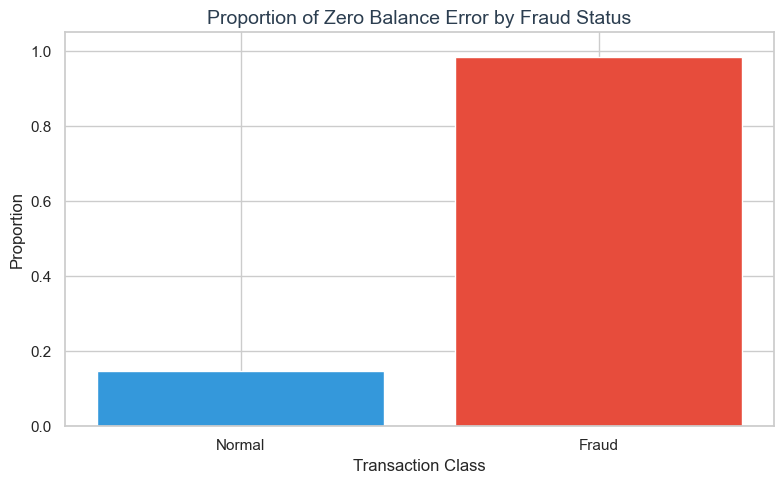

In [217]:
zero_error_rate = (
    df.assign(zero_balance_error=df['balance_error'] == 0)
      .groupby('isFraud')['zero_balance_error']
      .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    ['Normal', 'Fraud'],
    zero_error_rate.values,
    color=[SECONDARY, ACCENT]
)

plt.title("Proportion of Zero Balance Error by Fraud Status", fontsize=14, color=PRIMARY)
plt.ylabel("Proportion")
plt.xlabel("Transaction Class")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Transaction Size Relative to Account Balance

This feature measures the size of a transaction relative to the sender's
available balance, helping to identify account-draining behaviour.

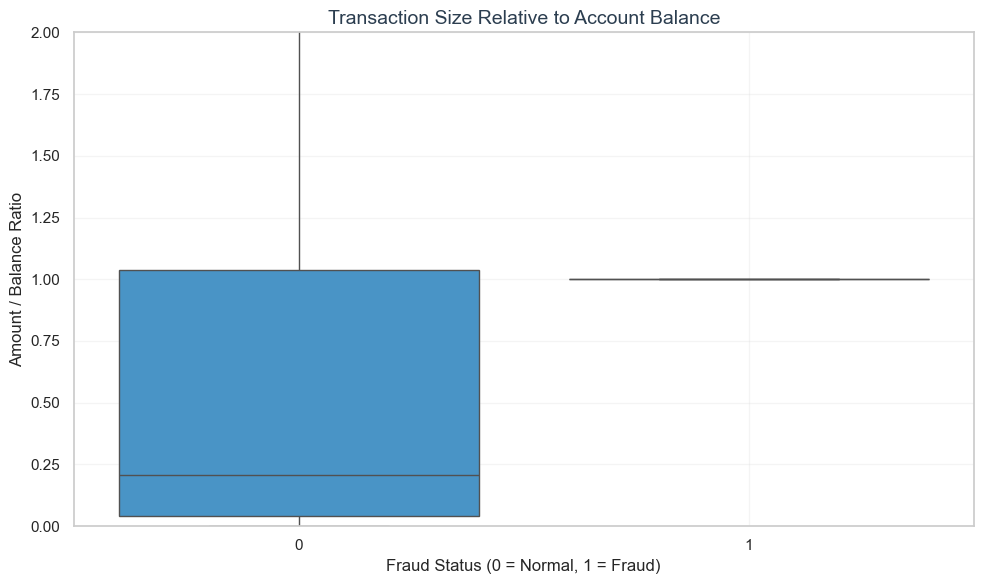

In [ ]:
plot_df = df[
    (df['amount_to_balance_ratio'] < 5) &
    (df['amount_to_balance_ratio'] >= 0)
].copy()

df_fraud = plot_df[plot_df['isFraud'] == 1]
df_normal = plot_df[plot_df['isFraud'] == 0].sample(200000, random_state=42)

plot_df = pd.concat([df_fraud, df_normal])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x='isFraud',
    y='amount_to_balance_ratio',
    hue='isFraud',                
    palette=[SECONDARY, ACCENT],
    showfliers=False,
    legend=False                 
)

plt.title("Transaction Size Relative to Account Balance", fontsize=14, color=PRIMARY)
plt.xlabel("Fraud Status (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount / Balance Ratio")
plt.ylim(0, 2)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [219]:
df.groupby('isFraud')['amount_to_balance_ratio'].median()

isFraud
0    6.511566
1    0.999998
Name: amount_to_balance_ratio, dtype: float64

### Fraud Over Time

Analysing fraud over time helps identify whether fraudulent activity occurs
randomly or in coordinated bursts.

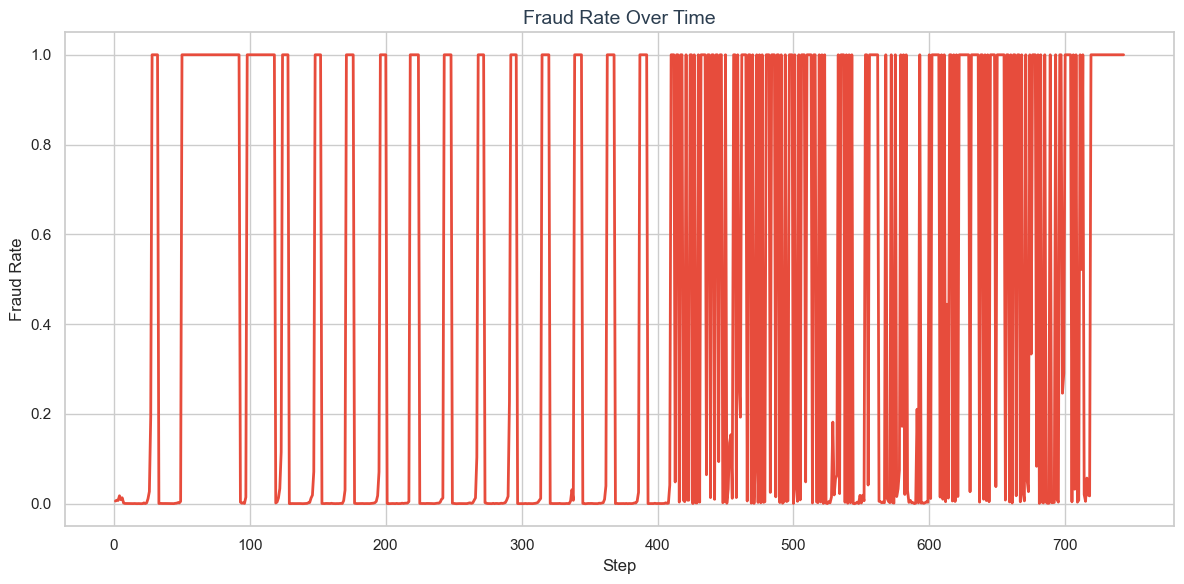

In [223]:
fraud_over_time = (
    df.groupby('step')['isFraud']
      .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(fraud_over_time.index, fraud_over_time.values, color=ACCENT, linewidth=2)

plt.title("Fraud Rate Over Time", fontsize=14, color=PRIMARY)
plt.xlabel("Step")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

Fraud activity appears temporally clustered rather than uniformly
distributed, suggesting coordinated attack behaviour.

### Correlation Analysis

A correlation heatmap is used to explore relationships among key numerical
features and engineered fraud indicators.

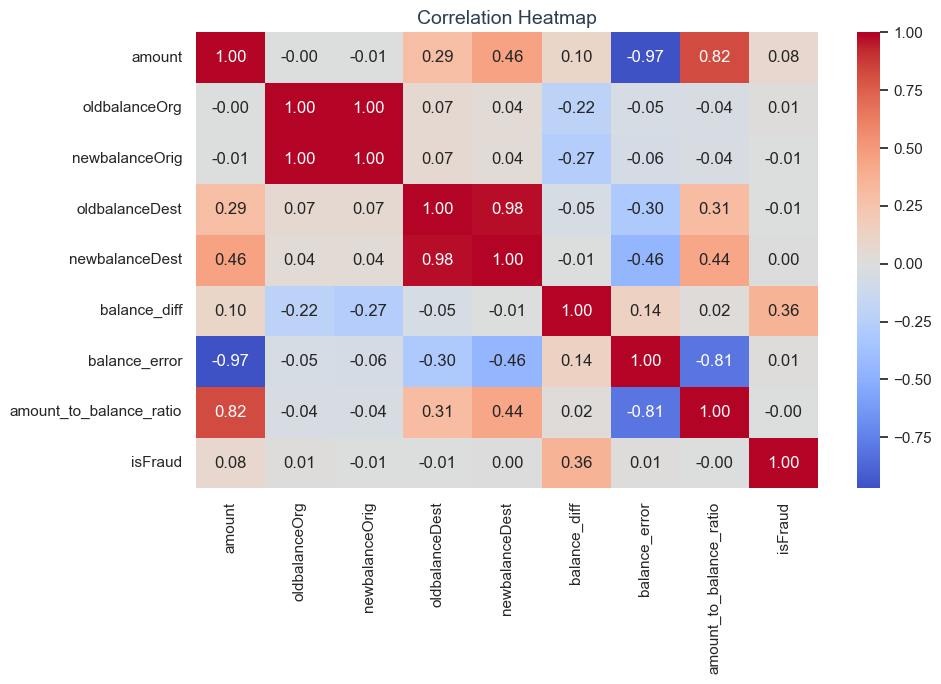

In [224]:
features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balance_diff',
    'balance_error',
    'amount_to_balance_ratio',
    'isFraud'
]

corr = df[features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=14, color=PRIMARY)
plt.tight_layout()
plt.show()

### Top Fraud Receivers

Repeated destination accounts may suggest mule accounts or recipient hubs
within fraudulent transaction flows.

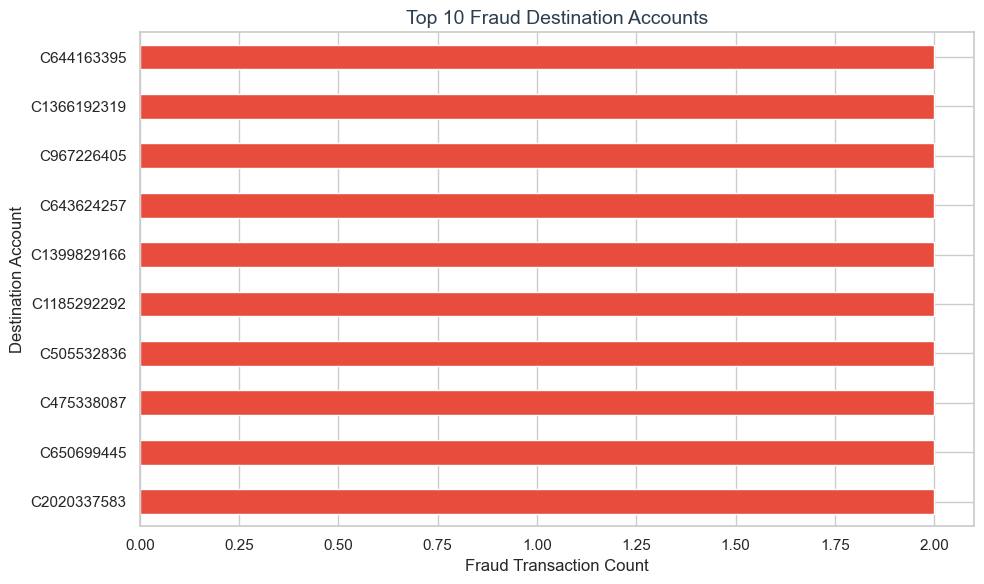

In [225]:
fraud_receivers = (
    df[df['isFraud'] == 1]
    .groupby('nameDest')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

fraud_receivers.sort_values().plot(kind='barh', color=ACCENT)

plt.title("Top 10 Fraud Destination Accounts", fontsize=14, color=PRIMARY)
plt.xlabel("Fraud Transaction Count")
plt.ylabel("Destination Account")
plt.tight_layout()
plt.show()

## Key Findings

- Fraud is highly concentrated in TRANSFER and CASH_OUT transactions.
- Fraudulent transactions tend to occur at higher transaction amounts.
- Approximately 98% of fraud transactions exhibit zero balance error.
- Fraud transactions typically transfer nearly the full sender balance.
- Fraud activity appears in temporal clusters rather than randomly.
- Repeated sender and receiver accounts suggest network-based fraud behaviour.

## Next Steps

The analysis highlights several strong behavioural indicators that can support
fraud detection models. Recommended next steps include:

- building supervised classification models
- handling severe class imbalance carefully
- testing engineered features in model training
- combining rule-based and machine learning approaches
- exploring graph or network-based fraud detection methods

In [ ]:

model_df = df.copy()

# 1. Drop identifier columns
drop_cols = ['nameOrig', 'nameDest']
model_df = model_df.drop(columns=drop_cols, errors='ignore')

# 2. Optional: drop columns that may cause leakage for baseline modelling
# Keep them in a second version later if you want to compare model performance
baseline_drop_cols = ['isFlaggedFraud', 'balance_error', 'zero_balance_error']
baseline_df = model_df.drop(columns=baseline_drop_cols, errors='ignore')

# 3. One-hot encode transaction type
baseline_df = pd.get_dummies(baseline_df, columns=['type'], drop_first=True)

# 4. Ensure boolean columns become integers
bool_cols = baseline_df.select_dtypes(include='bool').columns
baseline_df[bool_cols] = baseline_df[bool_cols].astype(int)

# 5. Final check
print("Baseline modelling dataset shape:", baseline_df.shape)
print("\nData types:\n", baseline_df.dtypes)
print("\nMissing values:\n", baseline_df.isnull().sum().sort_values(ascending=False).head(10))

baseline_df.head()

Baseline modelling dataset shape: (6362620, 15)

Data types:
 step                         int64
amount                     float64
oldbalanceOrg              float64
newbalanceOrig             float64
oldbalanceDest             float64
newbalanceDest             float64
isFraud                      int64
balance_diff               float64
high_amount                  int64
log_amount                 float64
amount_to_balance_ratio    float64
type_CASH_OUT                int64
type_DEBIT                   int64
type_PAYMENT                 int64
type_TRANSFER                int64
dtype: object

Missing values:
 step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
balance_diff      0
high_amount       0
log_amount        0
dtype: int64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_diff,high_amount,log_amount,amount_to_balance_ratio,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0,9.194276,0.057834,0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0,7.531166,0.087731,0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,181.00,0,5.204007,0.994505,0,0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,0,5.204007,0.994505,1,0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0,9.364703,0.280788,0,0,1,0


In [229]:
# Save baseline dataset for modelling
baseline_df.to_csv("../data/processed/fraud_baseline_model_data.csv", index=False)
